In [8]:

import datajoint as dj
dj.config.load('/Users/neurozmar/Secrets/dj_local_conf_NDNF_behavior_HUN-REN_cloud.json')#dj_local_conf_NDNF_behavior_KOKI.json #dj_local_conf_NDNF_behavior_HUN
dj.conn() 
direction_dict = {'LR':'Left - Right',
                  'RL':'Right - Left',
                  'AP':'Anterior - Posterior',
                  'PA':'Posterior - Anterior'}
#%% import necessary packages
import matplotlib.pyplot as plt
import pandas as pd
from ndnf_pipeline import lab, experiment
from ndnf_pipeline import behavior_analysis

import numpy as np
# connect to the database

[2026-06-05 18:20:12,978][INFO]: DataJoint is configured from /Users/neurozmar/Secrets/dj_local_conf_NDNF_behavior_HUN-REN_cloud.json


'Fentről-Le irány'

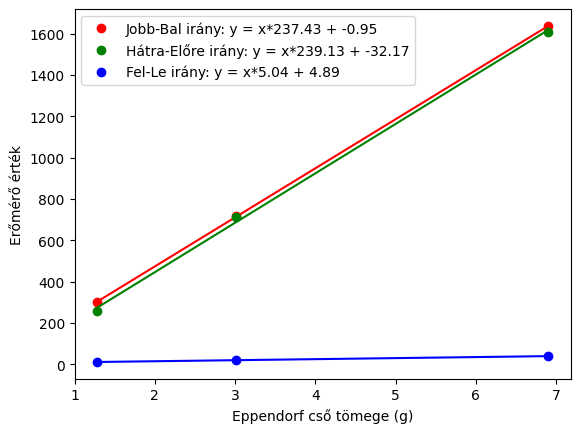

In [ ]:
calibration_dict = (lab.Device().DeviceCalibration()&{'calibration_date': datetime.datetime(2026, 5, 1)}).fetch1('calibration_dict')
direction_dict = {'LR':'Bal-Jobb irány',
                  'RL':'Jobb-Bal irány',
                  'AP':'Előre-Hátra irány',
                  'PA':'Hátra-Előre irány',
                  'DV': 'Fel-Le irány',
                  'VD': 'Len-Fel irány'}
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
for k,c in zip(calibration_dict.keys(),['r','g','b']):
    x = calibration_dict[k]['vals']
    y = calibration_dict[k]['g']
    p = np.polyfit(x, y, 1)
    ax.plot(x, y, c+'o', label='{}: y = {:.2f}*x + {:.2f}'.format(direction_dict[calibration_dict[k]['direction']], p[0], p[1]))
    ax.plot(x, np.polyval(p, x), c+'-')#, label=f'{k} fit')
    #print(f'{k}: {calibration_dict[k]}')
plt.xlabel('Erőmérő érték')
plt.ylabel('Eppendorf cső tömege (g)')
plt.legend()

In [9]:
#behavior_analysis.BlockStatistics.drop()

Text(0, 0.5, 'Number of Trials')

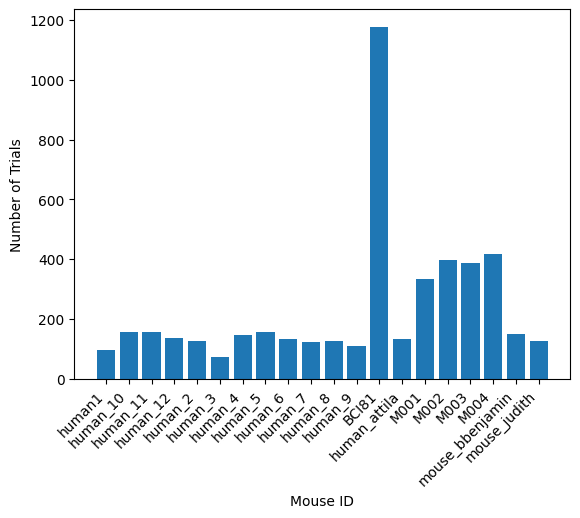

In [10]:
# find the mouse IDs that have been used in the experiment and count the number of trials for each mouse, then plot a bar graph
mouse_IDs = lab.Subject.fetch('subject_id')
trial_nums = []
for m in mouse_IDs:
    trial_nums.append(len((experiment.SessionTrial()&{'subject_id':m})))
trial_nums = np.array(trial_nums)
needed_mice = trial_nums>0

fig = plt. figure()
plt.bar(mouse_IDs[needed_mice], trial_nums[needed_mice])
plt.xticks(rotation=45, ha="right")
plt.xlabel('Mouse ID')
plt.ylabel('Number of Trials')


In [60]:
lab.Subject().fetch('subject_id')

array(['human1', 'human_10', 'human_11', 'human_12', 'human_2', 'human_3',
       'human_4', 'human_5', 'human_6', 'human_7', 'human_8', 'human_9',
       'M015', 'M016', 'M017', 'M018', 'M019', 'M020', 'M021', 'M022',
       'M023', 'M024', 'BCI81', 'human_attila', 'M001', 'M002', 'M003',
       'M004', 'M005', 'M006', 'M007', 'M008', 'M009', 'M010', 'M011',
       'M012', 'M013', 'M014', 'mouse_bbenjamin', 'mouse_judith'],
      dtype=object)

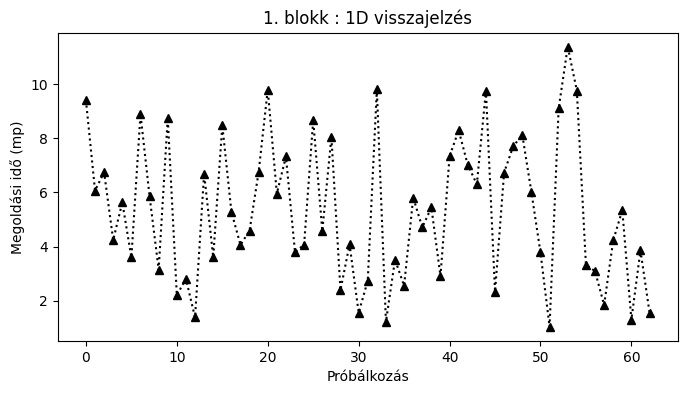

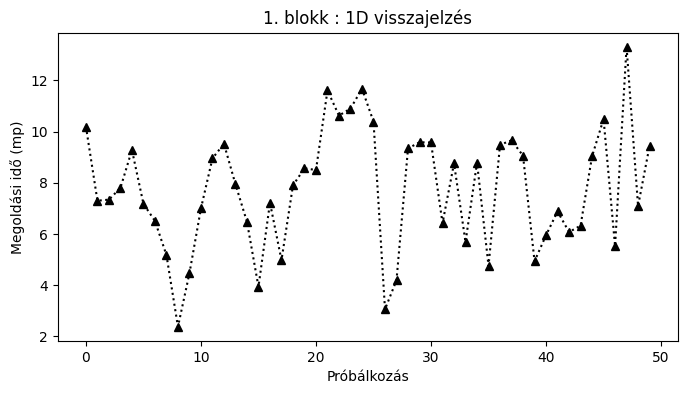

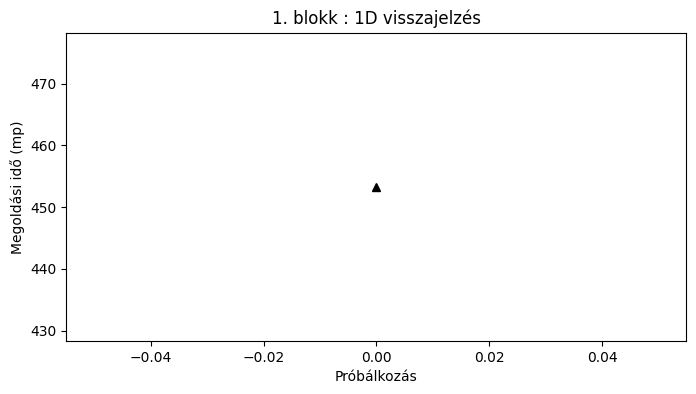

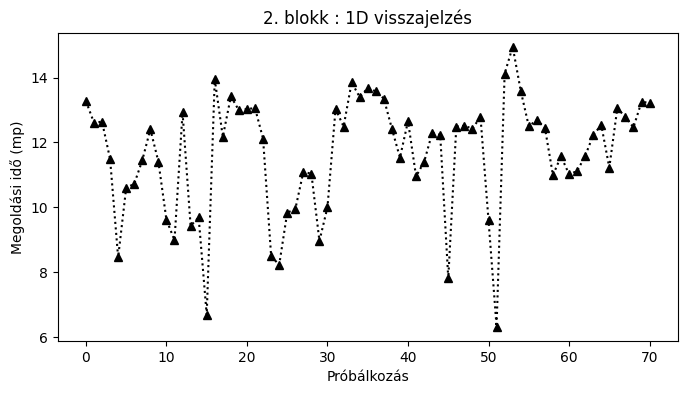

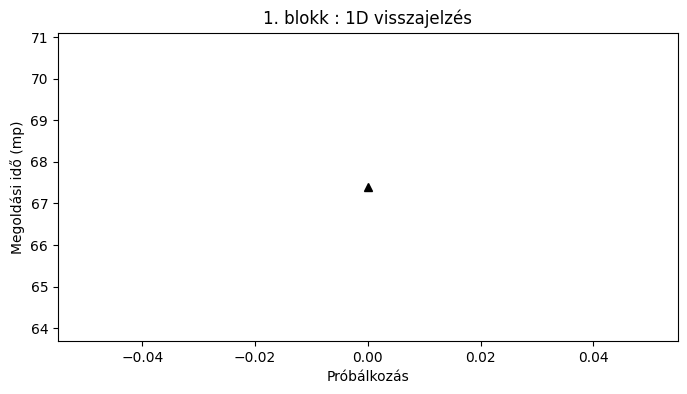

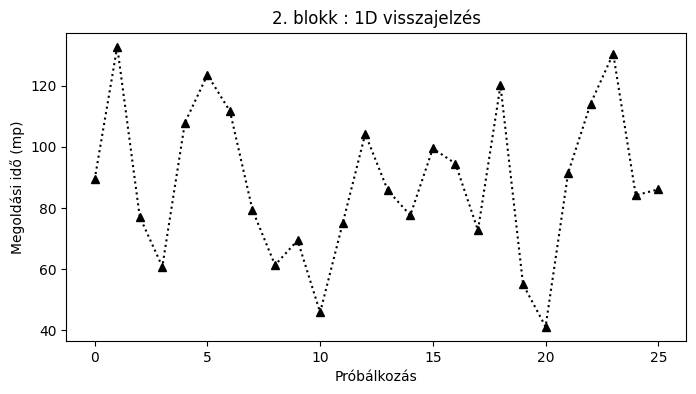

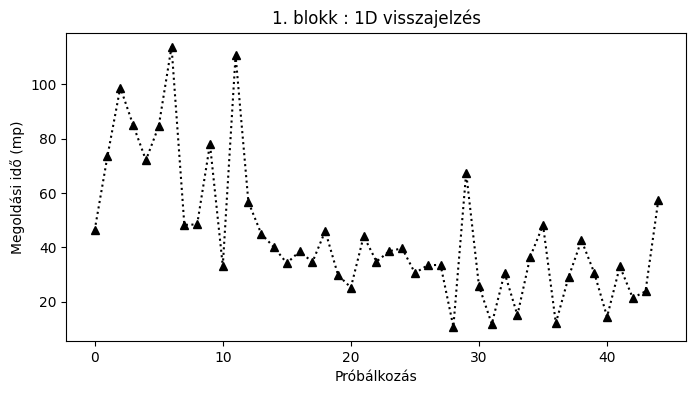

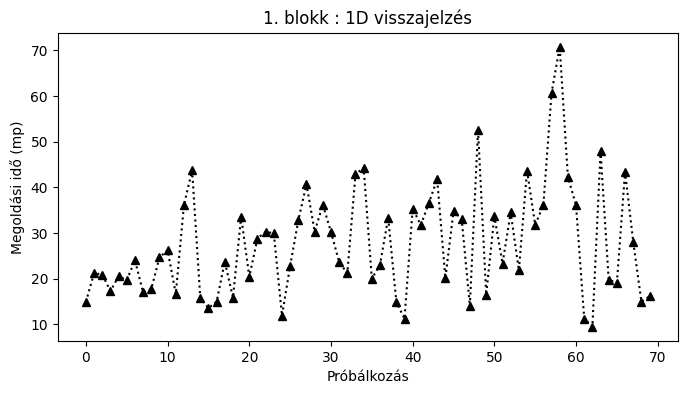

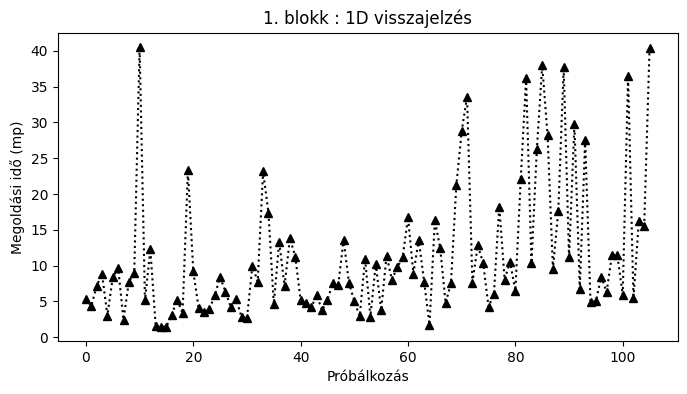

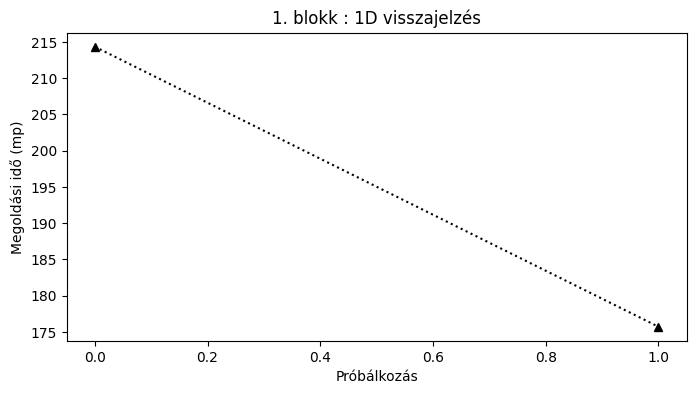

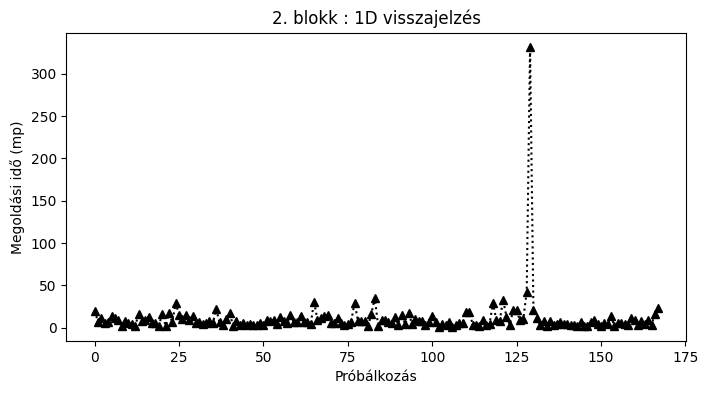

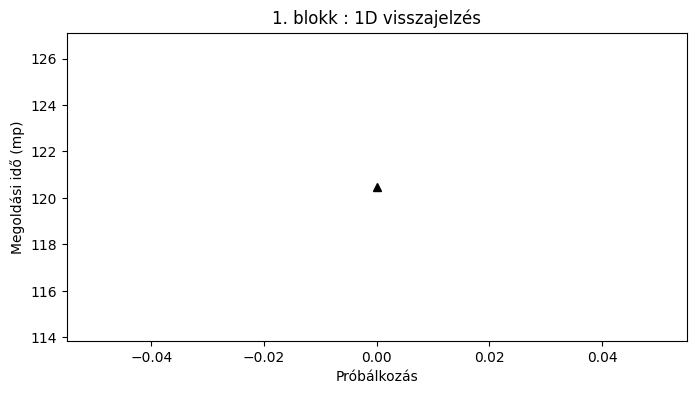

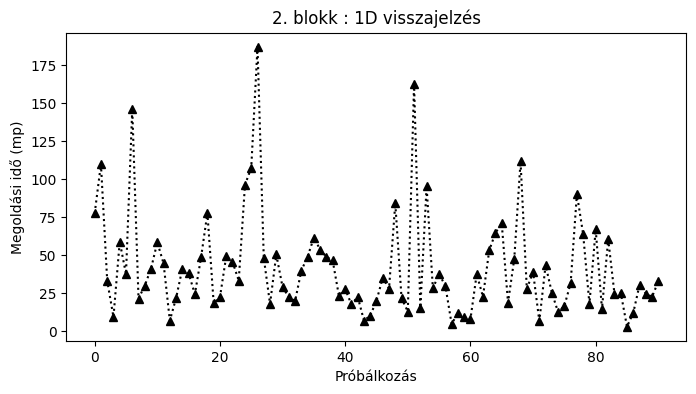

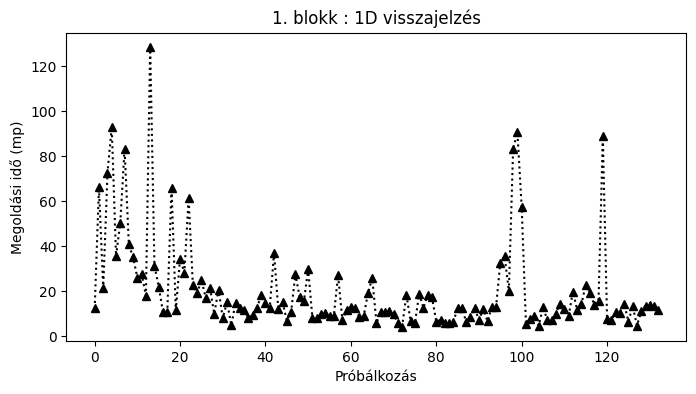

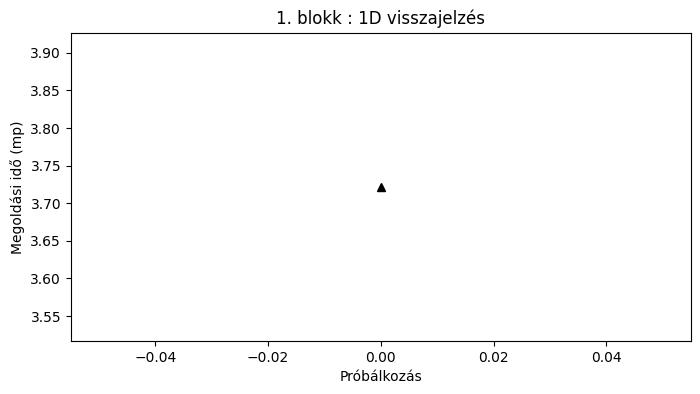

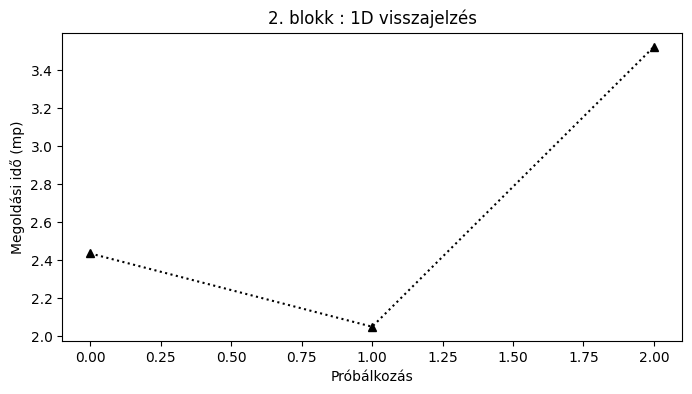

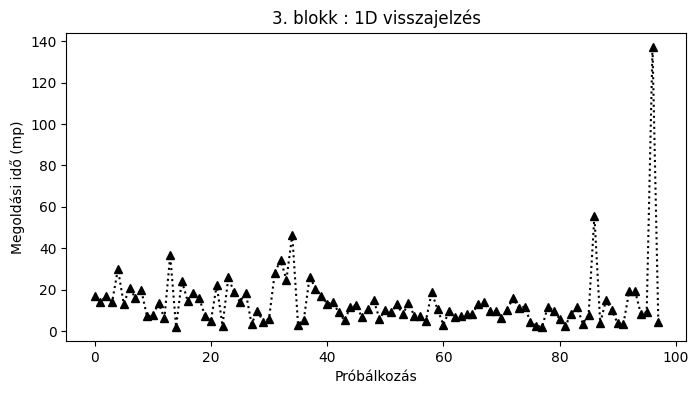

In [61]:
feedback_names_dict = {'2D_speed': '2D visszajelzés', 
                       '1D_speed': '1D visszajelzés', 
                       '0D_speed': 'nincs visszajelzés', 
                       '1D_position': '1D visszajelzés nehezített', 
                       '2D_position': '2D visszajelzés nehezített'}

subject_id = 'human_4'
subject_id = 'BCI81'
sessions = (experiment.Session()&{'subject_id':subject_id}).fetch('session')
for session in sessions:
    block_dict_list = (experiment.Block()&{'subject_id':subject_id, 'session':session}).fetch(as_dict=True)
    for block_dict in block_dict_list:
        block_num = block_dict['block']
        feedback_type = block_dict['feedback_type']
        rewarded_trial, time_to_reward = (experiment.TrialEvent()*experiment.BehaviorTrial()*experiment.Block()&{'subject_id':subject_id,'trial_event_type':'threshold crossing','block':block_num,'session':session}).fetch('trial','trial_event_time') 
        fig = plt.figure(figsize = (8,4))
        ax1 = fig.add_subplot(1,1,1)
        ax1.plot(time_to_reward,'^k:')#,color = 'blue')
        ax1.set_title(f'{block_num+1}. blokk : {feedback_names_dict.get(feedback_type, feedback_type)}')
        ax1.set_xlabel('Próbálkozás')
        ax1.set_ylabel('Megoldási idő (mp)')
    #y tengelyt is feliratozni


# FELADAT
# vedd ki az első megoldási időt minden blokkból, és hasonlítsd össze a különböző feedback típusok között. 
# vedd ki az utolsó előtti megoldási időt minden blokkból, és hasonlítsd össze a különböző feedback típusok között.  (vagy átlagold az utolsó 5 megoldási időt.)
# találd meg az első olyan próbálkozást, ami fele olyan sokáig tart, mint az első megoldási idő, és hasonlítsd össze a különböző feedback típusok között.
# iterálj végig a különböző emberek között, és írasd ki az összes fentit

In [12]:
behavior_analysis.BlockStatistics()*experiment.Block()*experiment.FeedbackType()

subject_id,session session number - A session is defined as a recording/behavior session with a maximum of 60 minutes break between recordings,"block block number within session, ordered chronologically",feedback_type,time_to_first_reward (s) threshold crossing time in the first rewarded trial,time_to_last_rewards (s) median threshold crossing time over last 5 rewarded trials,n_rewarded_trials number of rewarded trials in the block,task_setting_id,block_start_time (s) relative to session beginning,block_end_time (s) relative to session beginning,"feedback_dimensions 1, 2, 0=boolean/unspecified","feedback_modality 'speed', 'position', 'unspecified'",feedback_description
BCI81,0,0,1D_speed,9.40701,3.85802,63,0,0.00000,2805.75600,1,speed,1D accumulating/speed feedback
BCI81,1,0,1D_speed,10.19600,9.03299,50,0,0.00000,1436.49600,1,speed,1D accumulating/speed feedback
BCI81,2,0,1D_speed,453.29200,None,1,0,0.00000,456.42198,1,speed,1D accumulating/speed feedback
BCI81,2,1,1D_speed,13.27501,12.77501,71,1,1066.98998,2114.40899,1,speed,1D accumulating/speed feedback
BCI81,3,0,1D_speed,67.40198,None,1,0,0.00000,70.39498,1,speed,1D accumulating/speed feedback
BCI81,3,1,1D_speed,89.30899,91.44800,26,1,274.64198,2643.14800,1,speed,1D accumulating/speed feedback
BCI81,4,0,1D_speed,46.31702,23.77402,45,0,0.00000,2143.79802,1,speed,1D accumulating/speed feedback


['human_10' 'human_11' 'human_12' 'human_4' 'human_5' 'human_6' 'human_7'
 'human_8' 'human_9']
['human1' 'human1' 'human1' 'human1' 'human1' 'human_10' 'human_11'
 'human_12' 'human_2' 'human_2' 'human_2' 'human_2' 'human_3' 'human_3'
 'human_4' 'human_5' 'human_6' 'human_7' 'human_8']
['human_10' 'human_11' 'human_4' 'human_5' 'human_6' 'human_9']
['human_10' 'human_11' 'human_12' 'human_12' 'human_4' 'human_5' 'human_7']
['human_10' 'human_11' 'human_4' 'human_5' 'human_6' 'human_7' 'human_8'
 'human_9']

=== time_to_first_reward ===
Kruskal-Wallis: H=7.071, p=0.1322
Pairwise Mann-Whitney U (Bonferroni corrected):
  2D_speed vs 1D_speed: U=129.0, p=0.0344, p_corr=0.3441  ns
  2D_speed vs 0D_speed: U=42.0, p=0.0879, p_corr=0.8791  ns
  2D_speed vs 1D_position: U=37.0, p=0.6065, p_corr=1.0000  ns
  2D_speed vs 2D_position: U=55.0, p=0.0745, p_corr=0.7445  ns
  1D_speed vs 0D_speed: U=54.0, p=0.8770, p_corr=1.0000  ns
  1D_speed vs 1D_position: U=39.0, p=0.1204, p_corr=1.0000  ns
  1D_

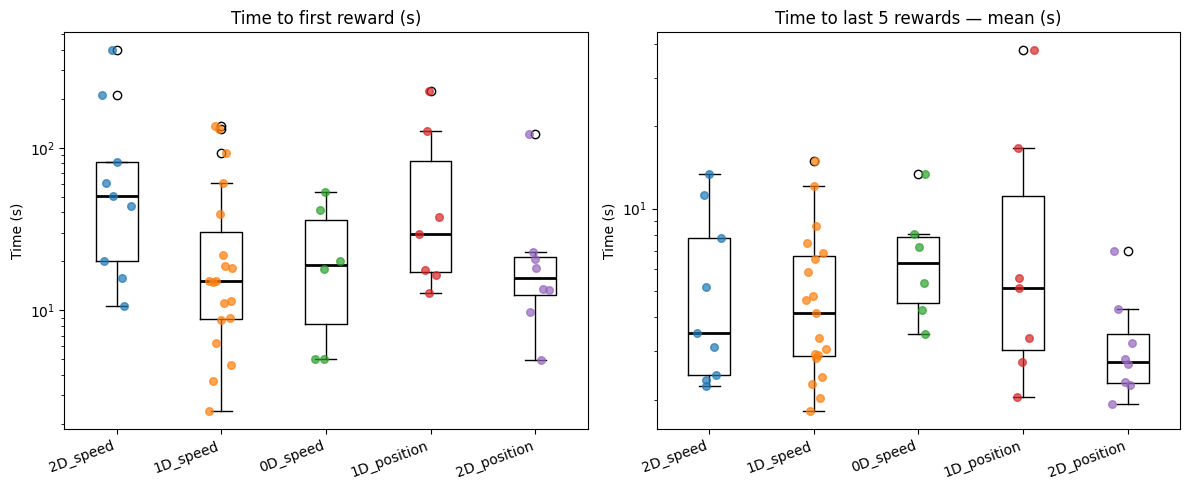

In [13]:
from scipy import stats
from itertools import combinations

# --- collect data ---
data_first, data_last = {}, {}
#feedback_types = experiment.FeedbackType().fetch('feedback_type')
feedback_types = ['2D_speed','1D_speed','0D_speed', '1D_position','2D_position' ]

min_needed_trials = 10 # skip sessions with too few rewards for reliable stats
minimum_block_num = 1 #skip first block because humans see the taks there first

for feedback_type in feedback_types:
    if feedback_type == 'unspecified':
        continue
    time_to_first_reward, time_to_last_rewards, block, subject_ids, n_rewarded_trials = (
        behavior_analysis.BlockStatistics() * experiment.Block() * experiment.FeedbackType()
        & {'feedback_type': feedback_type}
    ).fetch('time_to_first_reward', 'time_to_last_rewards', 'block', 'subject_id', 'n_rewarded_trials')
    if len(subject_ids)==0:
        continue
    needed_subject = []
    for s in subject_ids:
        if 'human' in s.lower() and 'attila' not in s.lower() and 'bbenjamin' not in s.lower():
            needed_subject.append(True)
        else:
            needed_subject.append(False)
    needed_subject = np.asarray(needed_subject)
    needed = (block >= minimum_block_num) & (n_rewarded_trials > min_needed_trials)
    needed = needed & needed_subject
    print(subject_ids[needed])
    first = time_to_first_reward[needed].astype(float)
    last  = time_to_last_rewards[needed].astype(float)
    if len(first) > 0:
        data_first[feedback_type] = first
        data_last[feedback_type]  = last

labels = list(data_first.keys())
x = np.arange(len(labels))

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, data, title in zip(axes,
                            [data_first, data_last],
                            ['Time to first reward (s)', 'Time to last 5 rewards — mean (s)']):
    vals = [data[k] for k in labels]
    bp = ax.boxplot(vals, positions=x, widths=0.4, patch_artist=False,
                    medianprops=dict(color='black', linewidth=2))
    for i, v in enumerate(vals):
        ax.scatter(np.random.normal(i, 0.07, len(v)), v, s=30, alpha=0.7, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_title(title)
    ax.set_ylabel('Time (s)')
    ax.set_yscale('log')

plt.tight_layout()

# --- statistics ---
for data, name in [(data_first, 'time_to_first_reward'), (data_last, 'time_to_last_rewards')]:
    vals = [data[k] for k in labels]
    print(f'\n=== {name} ===')
    if len(vals) > 1:
        h, p_kw = stats.kruskal(*vals)
        print(f'Kruskal-Wallis: H={h:.3f}, p={p_kw:.4f}')
        pairs = list(combinations(labels, 2))
        n_pairs = len(pairs)
        print('Pairwise Mann-Whitney U (Bonferroni corrected):')
        for a, b in pairs:
            u, p = stats.mannwhitneyu(data[a], data[b], alternative='two-sided')
            p_corr = min(p * n_pairs, 1.0)
            print(f'  {a} vs {b}: U={u:.1f}, p={p:.4f}, p_corr={p_corr:.4f}  {"*" if p_corr < 0.05 else "ns"}')
    else:
        print('Only one group — no test performed')

plt.show()


In [37]:
behavior_analysis.BlockStatistics() * experiment.Block() * experiment.FeedbackType()&{'subject_id':'human_4', 'session':0}

subject_id,session session number - A session is defined as a recording/behavior session with a maximum of 60 minutes break between recordings,"block block number within session, ordered chronologically",feedback_type,time_to_first_reward (s) threshold crossing time in the first rewarded trial,time_to_last_rewards (s) median threshold crossing time over last 5 rewarded trials,n_rewarded_trials number of rewarded trials in the block,task_setting_id,block_start_time (s) relative to session beginning,block_end_time (s) relative to session beginning,"feedback_dimensions 1, 2, 0=boolean/unspecified","feedback_modality 'speed', 'position', 'unspecified'",feedback_description
human_4,0,0,1D_speed,7.34000,5.76998,25,0,0.00000,168.32400,1,speed,1D accumulating/speed feedback
human_4,0,1,2D_speed,209.87200,13.32602,25,1,477.90813,1142.01414,2,speed,2D accumulating/speed feedback
human_4,0,2,0D_speed,41.43200,3.47002,25,2,1443.91229,1723.91629,0,speed,Reward-only boolean feedback with speed
human_4,0,3,1D_speed,92.98800,8.61802,25,3,1919.49715,2469.84314,1,speed,1D accumulating/speed feedback
human_4,0,4,1D_position,127.21002,37.91002,15,4,2681.34938,3525.45936,1,position,1D instantaneous/position feedback
human_4,0,5,2D_position,20.72598,2.68800,26,5,3780.52810,3925.63408,2,position,2D instantaneous/position feedback



=== time_to_first_reward ===
Friedman (n=3 paired): chi2=5.600, p=0.2311
Pairwise Wilcoxon signed-rank (Bonferroni corrected, 10 comparisons):
  2D_speed vs 1D_speed: W=4.0, p=0.0547, p_corr=0.5469  n=8  ns
  2D_speed vs 0D_speed: W=1.0, p=0.1250, p_corr=1.0000  n=5  ns
  2D_speed vs 1D_position: W=3.0, p=0.6250, p_corr=1.0000  n=4  ns
  2D_speed vs 2D_position: W=7.0, p=0.1484, p_corr=1.0000  n=8  ns
  1D_speed vs 0D_speed: W=3.0, p=0.3125, p_corr=1.0000  n=5  ns
  1D_speed vs 1D_position: W=4.0, p=0.8750, p_corr=1.0000  n=4  ns
  1D_speed vs 2D_position: W=13.0, p=0.9375, p_corr=1.0000  n=7  ns
  0D_speed vs 1D_position: only 3 paired subjects — skipped
  0D_speed vs 2D_position: W=7.0, p=1.0000, p_corr=1.0000  n=5  ns
  1D_position vs 2D_position: only 3 paired subjects — skipped

=== time_to_last_rewards ===
Friedman (n=3 paired): chi2=3.467, p=0.4830
Pairwise Wilcoxon signed-rank (Bonferroni corrected, 10 comparisons):
  2D_speed vs 1D_speed: W=16.0, p=0.8438, p_corr=1.0000  n=8 

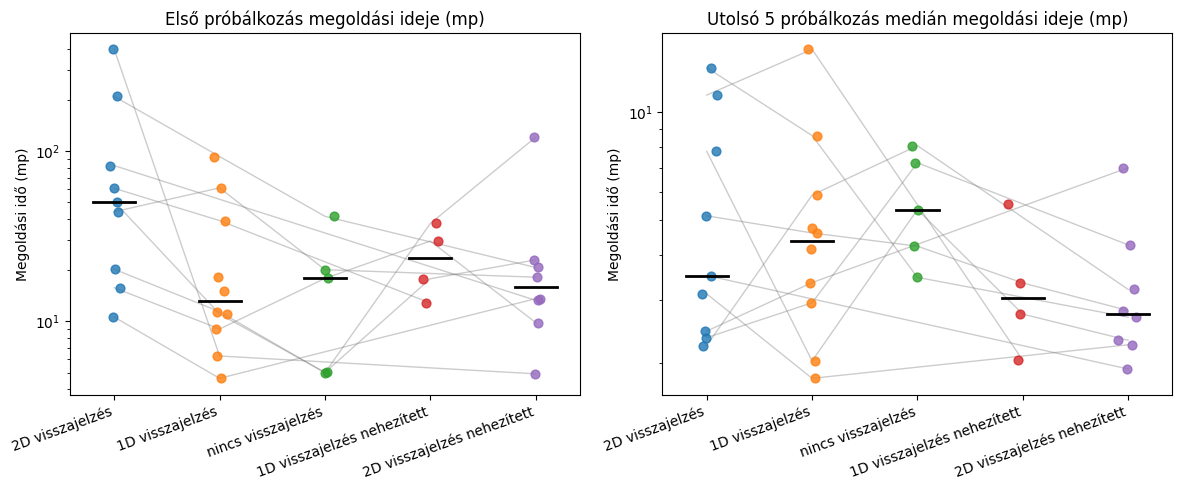

In [39]:
from scipy import stats
from itertools import combinations

# --- collect data as {feedback_type: {subject_id: value}} ---
data_first, data_last = {}, {}
feedback_names_dict = {'2D_speed': '2D visszajelzés', 
                       '1D_speed': '1D visszajelzés', 
                       '0D_speed': 'nincs visszajelzés', 
                       '1D_position': '1D visszajelzés nehezített', 
                       '2D_position': '2D visszajelzés nehezített'}
feedback_types = ['2D_speed','1D_speed','0D_speed', '1D_position','2D_position' ]
min_needed_trials = 20
minimum_block_num = 1

for feedback_type in feedback_types:
    if feedback_type == 'unspecified':
        continue
    time_to_first_reward, time_to_last_rewards, block, subject_ids, n_rewarded_trials = (
        behavior_analysis.BlockStatistics() * experiment.Block() * experiment.FeedbackType()
        & { 'feedback_type': feedback_type}
    ).fetch('time_to_first_reward', 'time_to_last_rewards', 'block', 'subject_id', 'n_rewarded_trials')

    if len(subject_ids) == 0:
        continue

    subj_first, subj_last = {}, {}
    for subj, b, first, last, n in zip(subject_ids, block, time_to_first_reward, time_to_last_rewards, n_rewarded_trials):
        if 'human' not in subj.lower() or 'attila' in subj.lower() or 'bbenjamin' in subj.lower():
            continue
        if b < minimum_block_num or n <= min_needed_trials:
            continue
        if subj not in subj_first or b > subj_first[subj][0]:  # keep last qualifying block
            subj_first[subj] = (b, float(first))
            subj_last[subj]  = (b, float(last))

    if subj_first:
        data_first[feedback_type] = {s: v for s, (_, v) in subj_first.items()}
        data_last[feedback_type]  = {s: v for s, (_, v) in subj_last.items()}

labels = list(data_first.keys())
labels_on_plot = [feedback_names_dict.get(lbl, lbl) for lbl in labels]
x = np.arange(len(labels))

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, title in zip(axes,
                            [data_first, data_last],
                            ['Első próbálkozás megoldási ideje (mp)', 'Utolsó 5 próbálkozás medián megoldási ideje (mp)']):
    all_subjects = set().union(*[d.keys() for d in data.values()])

    # paired lines for subjects present in >1 condition
    for subj in all_subjects:
        xp = [i for i, lbl in enumerate(labels) if subj in data[lbl]]
        yp = [data[lbl][subj] for lbl in labels if subj in data[lbl]]
        if len(xp) > 1:
            ax.plot(xp, yp, color='gray', alpha=0.4, lw=1, zorder=1)

    for i, lbl in enumerate(labels):
        vals = list(data[lbl].values())
        ax.scatter(np.random.normal(i, 0.05, len(vals)), vals, s=40, alpha=0.8, zorder=3)
        ax.plot([i - 0.2, i + 0.2], [np.median(vals)] * 2, color='black', lw=2, zorder=4)

    ax.set_xticks(x)
    ax.set_xticklabels(labels_on_plot, rotation=20, ha='right')
    ax.set_title(title)
    ax.set_ylabel('Megoldási idő (mp)')
    ax.set_yscale('log')

plt.tight_layout()

# --- statistics ---
for data, name in [(data_first, 'time_to_first_reward'), (data_last, 'time_to_last_rewards')]:
    print(f'\n=== {name} ===')
    if len(labels) < 2:
        print('Only one group — no test performed')
        continue

    # Friedman test on subjects present in all conditions
    if len(labels) >= 3:
        common = set.intersection(*[set(data[lbl].keys()) for lbl in labels])
        if len(common) >= 3:
            mat = [[data[lbl][s] for lbl in labels] for s in common]
            stat, p_fr = stats.friedmanchisquare(*zip(*mat))
            print(f'Friedman (n={len(common)} paired): chi2={stat:.3f}, p={p_fr:.4f}')

    # pairwise Wilcoxon signed-rank
    pairs = list(combinations(labels, 2))
    print(f'Pairwise Wilcoxon signed-rank (Bonferroni corrected, {len(pairs)} comparisons):')
    for a, b in pairs:
        shared = sorted(set(data[a].keys()) & set(data[b].keys()))
        if len(shared) < 4:
            print(f'  {a} vs {b}: only {len(shared)} paired subjects — skipped')
            continue
        ya = [data[a][s] for s in shared]
        yb = [data[b][s] for s in shared]
        w, p = stats.wilcoxon(ya, yb, alternative='two-sided')
        p_corr = min(p * len(pairs), 1.0)
        print(f'  {a} vs {b}: W={w:.1f}, p={p:.4f}, p_corr={p_corr:.4f}  n={len(shared)}  {"*" if p_corr < 0.05 else "ns"}')

plt.show()



=== Exponential fit ===

  first_trial_value:
    2D_speed vs 1D_speed: W=4.0, p=0.0547, p_corr=0.5469  n=8  ns
    2D_speed vs 0D_speed: W=6.0, p=0.8125, p_corr=1.0000  n=5  ns
    2D_speed vs 1D_position: W=4.0, p=0.8750, p_corr=1.0000  n=4  ns
    2D_speed vs 2D_position: W=7.0, p=0.2969, p_corr=1.0000  n=7  ns
    1D_speed vs 0D_speed: W=7.0, p=1.0000, p_corr=1.0000  n=5  ns
    1D_speed vs 1D_position: W=1.0, p=0.2500, p_corr=1.0000  n=4  ns
    1D_speed vs 2D_position: W=11.0, p=0.6875, p_corr=1.0000  n=7  ns
    0D_speed vs 1D_position: only 3 paired — skipped
    0D_speed vs 2D_position: W=7.0, p=1.0000, p_corr=1.0000  n=5  ns
    1D_position vs 2D_position: only 3 paired — skipped

  steady_state:
    2D_speed vs 1D_speed: W=17.0, p=0.9453, p_corr=1.0000  n=8  ns
    2D_speed vs 0D_speed: W=7.0, p=1.0000, p_corr=1.0000  n=5  ns
    2D_speed vs 1D_position: W=0.0, p=0.1250, p_corr=1.0000  n=4  ns
    2D_speed vs 2D_position: W=8.0, p=0.3750, p_corr=1.0000  n=7  ns
    1D_speed

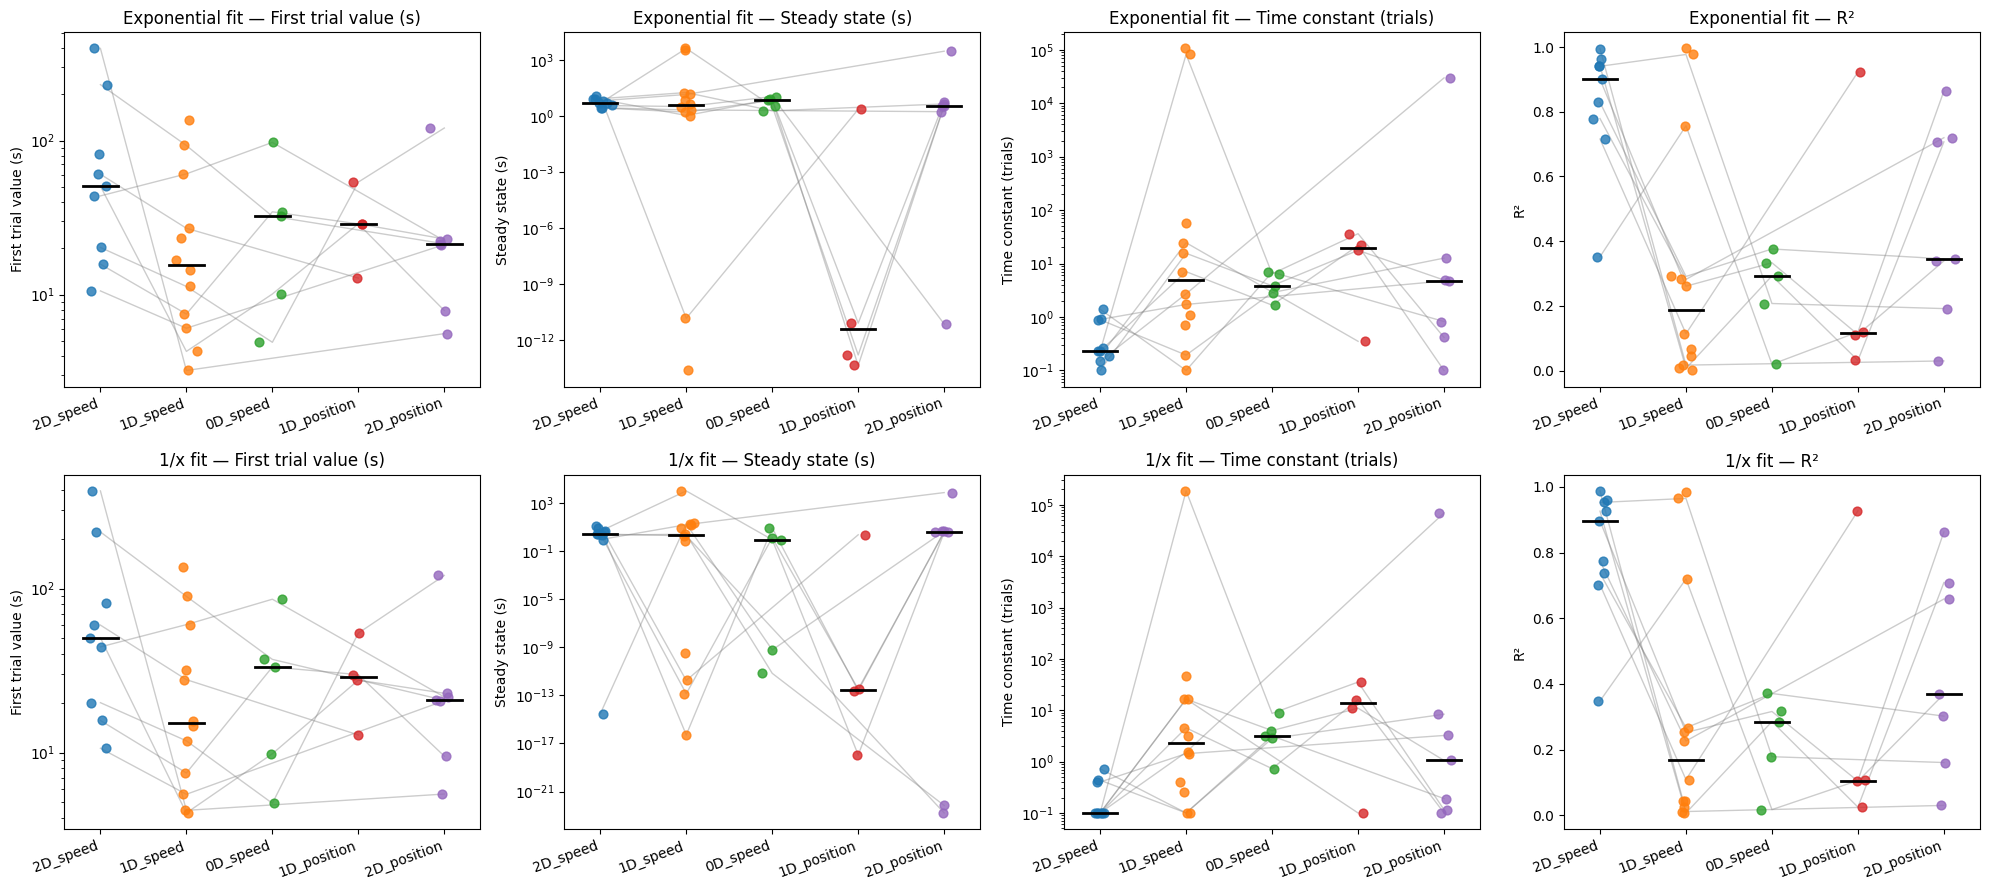

In [36]:
def collect_fit_data(part_table, feedback_types, minimum_block_num, min_needed_trials):
    params = ['first_trial_value', 'steady_state', 'time_constant', 'r_squared']  # added r_squared
    data = {p: {} for p in params}

    for feedback_type in feedback_types:
        if feedback_type == 'unspecified':
            continue
        first_vals, steady_states, time_consts, r_squareds, blocks, subject_ids, n_trials = (
            part_table * behavior_analysis.BlockStatistics() * experiment.Block() * experiment.FeedbackType()
            & {'session': 0, 'feedback_type': feedback_type}
        ).fetch('first_trial_value', 'steady_state', 'time_constant', 'r_squared',
                'block', 'subject_id', 'n_rewarded_trials')

        if len(subject_ids) == 0:
            continue

        subj_best = {}
        for subj, b, fv, ss, tc, r2, n in zip(subject_ids, blocks, first_vals, steady_states, time_consts, r_squareds, n_trials):
            if 'human' not in subj.lower() or b < minimum_block_num or n <= min_needed_trials:
                continue
            if subj not in subj_best or b > subj_best[subj][0]:
                subj_best[subj] = (b, float(fv), float(ss), float(tc), float(r2))

        if not subj_best:
            continue
        for i, p in enumerate(params):
            data[p][feedback_type] = {s: vals[i + 1] for s, vals in subj_best.items()}

    return data


def plot_and_test_fit(data, fit_name, axes_row):
    param_labels = {
        'first_trial_value': 'First trial value (s)',
        'steady_state':      'Steady state (s)',
        'time_constant':     'Time constant (trials)',
        'r_squared':         'R²',               # added
    }
    labels = list(data['first_trial_value'].keys())
    x = np.arange(len(labels))

    for ax, (param, title) in zip(axes_row, param_labels.items()):
        d = data[param]
        all_subjects = set().union(*[dd.keys() for dd in d.values()])

        for subj in all_subjects:
            xp = [i for i, lbl in enumerate(labels) if subj in d.get(lbl, {})]
            yp = [d[lbl][subj] for lbl in labels if subj in d.get(lbl, {})]
            if len(xp) > 1:
                ax.plot(xp, yp, color='gray', alpha=0.4, lw=1, zorder=1)

        for i, lbl in enumerate(labels):
            vals = list(d.get(lbl, {}).values())
            if not vals:
                continue
            ax.scatter(np.random.normal(i, 0.05, len(vals)), vals, s=40, alpha=0.8, zorder=3)
            ax.plot([i - 0.2, i + 0.2], [np.median(vals)] * 2, color='black', lw=2, zorder=4)

        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=20, ha='right')
        ax.set_title(f'{fit_name} — {title}')
        ax.set_ylabel(title)
        #ax.set_ylim([0.01,50] if 'time' in param or 'first_trial_value' in param or 'steady_state' in param else [0,1])   
        ax.set_yscale('log' if 'time' in param or 'first_trial_value' in param or 'steady_state' in param else 'linear')   
        

    print(f'\n=== {fit_name} ===')
    for param in param_labels:
        d = data[param]
        print(f'\n  {param}:')
        pairs = list(combinations(labels, 2))
        for a, b in pairs:
            shared = sorted(set(d.get(a, {}).keys()) & set(d.get(b, {}).keys()))
            if len(shared) < 4:
                print(f'    {a} vs {b}: only {len(shared)} paired — skipped')
                continue
            w, p = stats.wilcoxon([d[a][s] for s in shared], [d[b][s] for s in shared], alternative='two-sided')
            p_corr = min(p * len(pairs), 1.0)
            print(f'    {a} vs {b}: W={w:.1f}, p={p:.4f}, p_corr={p_corr:.4f}  n={len(shared)}  {"*" if p_corr < 0.05 else "ns"}')

min_needed_trials = 15
exp_data = collect_fit_data(behavior_analysis.BlockStatistics.ExpFit(), feedback_types, minimum_block_num, min_needed_trials)
inv_data = collect_fit_data(behavior_analysis.BlockStatistics.InvFit(), feedback_types, minimum_block_num, min_needed_trials)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))  # 4 columns now
plot_and_test_fit(exp_data, 'Exponential fit', axes[0])
plot_and_test_fit(inv_data, '1/x fit',         axes[1])
plt.tight_layout()
plt.show()


In [20]:
param_labels

NameError: name 'param_labels' is not defined